<a href="https://colab.research.google.com/github/Cora-DeMeter/Image_Identifier/blob/main/Imge_Idendifer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab use
Run cells from top to bottom. CPU works; a free GPU is optional. Downloaded datasets are cached only for the current Colab runtime. If the session disconnects, rerun earlier cells.

In [1]:
# Import necessary libraries for numerical operations, plotting, TensorFlow, Keras, model selection, and metrics.
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set a random seed for reproducibility across runs.
keras.utils.set_random_seed(42)

# Print the TensorFlow version, expected image shape, and available physical devices (CPU/GPU).
print('TensorFlow:', tf.__version__)
print('Target image shape: (64, 64, 3)')
print('Devices:', tf.config.list_physical_devices())

TensorFlow: 2.20.0
Target image shape: (64, 64, 3)
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from pathlib import Path
from PIL import Image

# Inform the user that direct archive download and Pillow (PIL) for image loading are being used.
print("Using direct archive download + Pillow image loading.")

Using direct archive download + Pillow image loading.


In [3]:
from google.colab import drive
# Mount Google Drive to access files stored in My Drive.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def find_dataset_root(search_root, expected_class_names):
    """
    Find the directory whose immediate subdirectories match the class names.
    This makes extraction robust even when an archive contains an extra folder.
    """
    search_root = Path(search_root)
    expected = set(expected_class_names)

    # Initialize candidates with the search_root itself
    candidates = [search_root]
    # Extend candidates by searching for all subdirectories within search_root
    candidates.extend(
        path for path in search_root.rglob("*")
        if path.is_dir()
    )

    # Iterate through potential root directories
    for candidate in candidates:
        try:
            # Get names of immediate subdirectories
            child_names = {
                path.name
                for path in candidate.iterdir()
                if path.is_dir()
            }
        except PermissionError:
            # Skip if there's a permission issue accessing a directory
            continue

        # If all expected class names are found as subdirectories, return this candidate
        if expected.issubset(child_names):
            return candidate

    # If no suitable root directory is found, raise an error
    raise FileNotFoundError(
        "Could not find the expected class folders after extraction. "
        f"Expected: {sorted(expected)}"
    )


def load_balanced_image_directory(
    data_dir,
    class_names,
    samples_per_class,
    image_size=(64, 64),
    seed=42
):
    """
    Load the same number of RGB images from each class folder, resizing them to a specified size.

    The directory must have this structure:

        data_dir/
            class_0/
            class_1/
            ...

    Images are resized to 64x64 and stored as uint8 arrays.
    """
    data_dir = Path(data_dir)
    # Initialize a random number generator for reproducibility.
    rng = np.random.default_rng(seed)

    images = []
    labels = []

    # Iterate through each class to load images
    for label, class_name in enumerate(class_names):
        class_dir = data_dir / class_name

        # Find all image files within the current class directory.
        image_paths = [
            path
            for path in class_dir.rglob("*")
            if path.is_file()
            and path.suffix.lower() in IMAGE_EXTENSIONS
        ]

        # Check if enough images are available for the requested sample count.
        if len(image_paths) < samples_per_class:
            raise ValueError(
                f"Class '{class_name}' has only {len(image_paths)} images, "
                f"but {samples_per_class} were requested."
            )

        # Shuffle image paths and load the required number of samples.
        rng.shuffle(image_paths)
        loaded = 0

        for image_path in image_paths:
            try:
                with Image.open(image_path) as image:
                    # Convert image to RGB, resize, and store as a NumPy array.
                    image = image.convert("RGB")
                    image = image.resize(
                        image_size,
                        Image.Resampling.BILINEAR
                    )
                    images.append(np.asarray(image, dtype=np.uint8))
                    labels.append(label)
                    loaded += 1
            except (OSError, ValueError):
                # Skip damaged or unsupported images.
                continue

            # Stop loading once the required samples_per_class are met.
            if loaded == samples_per_class:
                break

        # Check if enough readable images were loaded.
        if loaded < samples_per_class:
            raise RuntimeError(
                f"Only {loaded} readable images were found for "
                f"class '{class_name}'."
            )

    # Convert lists of images and labels to NumPy arrays.
    images = np.asarray(images, dtype=np.uint8)
    labels = np.asarray(labels, dtype=np.int64)

    # Randomly permute the order of images and labels to mix classes.
    order = rng.permutation(len(images))
    return images[order], labels[order]

## Load or generate the dataset
The data is kept as `uint8` until the student normalization step. A stratified split preserves class proportions in training and test data.

In [6]:
import zipfile
import os
from pathlib import Path

# Define separate archive filenames for training and testing datasets.
# Correcting the paths: training_set.zip should be for training, test_set.zip for testing.
training_archive_filename = '/content/drive/MyDrive/Summer USF/projec/training_set/training_set.zip'
test_archive_filename = '/content/drive/MyDrive/Summer USF/projec/test_set/test_set.zip'

# Create Path objects for the archive files.
training_archive_path = Path(training_archive_filename)
test_archive_path = Path(test_archive_filename)

# Check if the training archive exists.
if not training_archive_path.exists():
    print(f"Error: {training_archive_path} not found. Please upload '{training_archive_filename}' and rerun this cell.")
    # Initialize variables to None or default to prevent errors in subsequent cells if data is missing.
    x_train_raw, y_train, x_test_raw, y_test = None, None, None, None
    class_names = ['cats', 'dogs'] # Still define class_names for model definition.
    input_shape = (64, 64, 3)
    num_classes = len(class_names)
# Check if the test archive exists.
elif not test_archive_path.exists():
    print(f"Error: {test_archive_path} not found. Please upload '{test_archive_filename}' and rerun this cell.")
    # Initialize variables to None or default.
    x_train_raw, y_train, x_test_raw, y_test = None, None, None, None
    class_names = ['cats', 'dogs']
    input_shape = (64, 64, 3)
    num_classes = len(class_names)
else:
    # Define separate extraction paths for training and testing data.
    extracted_training_base_path = Path('/content/extracted_training_dataset')
    extracted_test_base_path = Path('/content/extracted_test_dataset')

    # Import shutil for directory operations.
    import shutil
    # Clean up any previously extracted training dataset to ensure a fresh extraction.
    if extracted_training_base_path.exists():
        shutil.rmtree(extracted_training_base_path)
    # Clean up any previously extracted test dataset.
    if extracted_test_base_path.exists():
        shutil.rmtree(extracted_test_base_path)

    # Create the directories for extraction.
    extracted_training_base_path.mkdir(parents=True, exist_ok=True)
    extracted_test_base_path.mkdir(parents=True, exist_ok=True)

    # Extract the training archive.
    print(f"Extracting {training_archive_path} to {extracted_training_base_path}...")
    with zipfile.ZipFile(training_archive_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_training_base_path)
    print("Training extraction complete.")

    # Extract the test archive.
    print(f"Extracting {test_archive_path} to {extracted_test_base_path}...")
    with zipfile.ZipFile(test_archive_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_test_base_path)
    print("Test extraction complete.")

    # Define the class names for the dataset.
    class_names = ['cats', 'dogs']

    # Use the find_dataset_root function to locate the actual directories containing 'cats' and 'dogs'.
    try:
        actual_training_data_dir = find_dataset_root(extracted_training_base_path, class_names)
        actual_test_data_dir = find_dataset_root(extracted_test_base_path, class_names)
    except FileNotFoundError as e:
        # Raise an error if class folders are not found within the extracted dataset.
        raise FileNotFoundError(
            f"Could not find 'cats' and 'dogs' class folders within the extracted dataset. "
            f"Please ensure the archives contain a structure like 'training_set/cats/' and 'test_set/cats/'. "
            f"Error details: {e}"
        )

    print(f"Identified training data directory containing classes: {actual_training_data_dir}")
    print(f"Identified test data directory containing classes: {actual_test_data_dir}")

    # Load training data using the custom load_balanced_image_directory function.
    print("Loading training data...")
    x_train_raw, y_train = load_balanced_image_directory(
        data_dir=actual_training_data_dir,
        class_names=class_names,
        samples_per_class=2000, # Number of samples to load per class for training.
        image_size=(64, 64),
        seed=42
    )

    # Load test data.
    print("Loading test data...")
    x_test_raw, y_test = load_balanced_image_directory(
        data_dir=actual_test_data_dir,
        class_names=class_names,
        samples_per_class=500, # Number of samples to load per class for testing.
        image_size=(64, 64),
        seed=42
    )

    # Define input shape and number of classes for the model.
    input_shape = (64, 64, 3)
    num_classes = len(class_names)

    print("Dataset loaded successfully!")
    # Print the shapes of the raw training and test image arrays.
    print("Training images:", x_train_raw.shape)
    print("Test images:", x_test_raw.shape)

Extracting /content/drive/MyDrive/Summer USF/projec/training_set/training_set.zip to /content/extracted_training_dataset...
Training extraction complete.
Extracting /content/drive/MyDrive/Summer USF/projec/test_set/test_set.zip to /content/extracted_test_dataset...
Test extraction complete.
Identified training data directory containing classes: /content/extracted_training_dataset/training_set
Identified test data directory containing classes: /content/extracted_test_dataset/test_set
Loading training data...
Loading test data...
Dataset loaded successfully!
Training images: (4000, 64, 64, 3)
Test images: (1000, 64, 64, 3)


The dataset is now loaded from the uploaded `archive.zip` file. The previous RPS dataset loading code is no longer active.

## Explore first
Random guessing gives about **33.3%** accuracy. Look for useful patterns, distracting backgrounds, similar classes, and possible shortcuts.

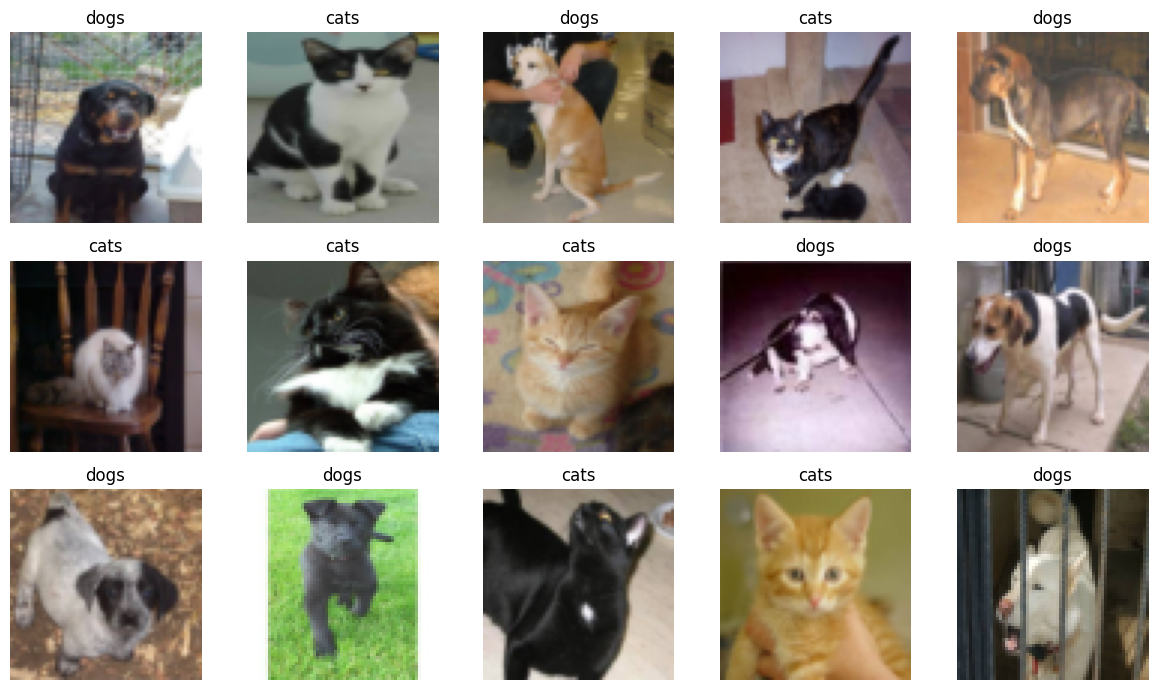

In [7]:
def show_examples(images, labels, class_names, rows=3, cols=5):
    total = min(rows * cols, len(images))
    plt.figure(figsize=(12, 7))
    for i in range(total):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_examples(x_train_raw, y_train, class_names)


## x_train_raw, y_train

## x_test_raw, y_test

## STUDENT TODO 1 — Normalize
Create `x_train` and `x_test`. Keep labels as integer class IDs.

In [8]:
# STUDENT TODO 1: NORMALIZE THE PIXELS
# Create float32 arrays x_train and x_test with values from 0 to 1.
# Mathematical hint: normalized_pixel = raw_pixel / 255.0

# Convert raw image pixel values (0-255) to float32 and scale them to the range [0, 1].
x_train = x_train_raw.astype(np.float32) / 255.0
x_test = x_test_raw.astype(np.float32) / 255.0

print('Normalization complete.')

Normalization complete.


In [9]:
# Convert integer labels into one-hot encoded format suitable for categorical cross-entropy loss.
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes=num_classes)

print('Labels one-hot encoded.')
print('y_train_one_hot shape:', y_train_one_hot.shape)
print('y_test_one_hot shape:', y_test_one_hot.shape)

Labels one-hot encoded.
y_train_one_hot shape: (4000, 2)
y_test_one_hot shape: (1000, 2)


In [10]:
def check_normalization(x_train, x_test):
    # Checks if the training and test data have been normalized correctly.
    if x_train is None or x_test is None:
        print('Normalization is not complete.')
        return False
    ok = (
        x_train.shape[1:] == (64, 64, 3) # Check if image dimensions are (64, 64, 3).
        and x_test.shape[1:] == (64, 64, 3)
        and x_train.dtype == np.float32 # Check if data type is float32.
        and x_test.dtype == np.float32
        and 0 <= float(x_train.min()) <= float(x_train.max()) <= 1 # Check if pixel values are in range [0, 1].
        and 0 <= float(x_test.min()) <= float(x_test.max()) <= 1
    )
    # Print details about the training data for debugging.
    print('Shape:', x_train.shape)
    print('dtype:', x_train.dtype)
    print('range:', float(x_train.min()), 'to', float(x_train.max()))
    print('Passed!' if ok else 'Check shape, dtype, and range again.')
    return ok

# Execute the normalization check.
check_normalization(x_train, x_test)

Shape: (4000, 64, 64, 3)
dtype: float32
range: 0.0 to 1.0
Passed!


True

## Optional augmentation
Augmentation creates small training-time transformations and can improve robustness. Test data must not be augmented.

In [11]:
# Optional: students may include this object near the start of their CNN.
# Define a data augmentation sequential model.
data_augmentation = keras.Sequential([
    # Randomly flip images horizontally.
    layers.RandomFlip('horizontal'),
    # Randomly rotate images by a small factor.
    layers.RandomRotation(0.05),
    # Randomly zoom in or out on images.
    layers.RandomZoom(0.08),
], name='data_augmentation')
print('Optional augmentation block is ready.')

Optional augmentation block is ready.


## STUDENT TODO 2 — Design the CNN
Try two convolution blocks and 6–8 epochs. Your architecture is a testable hypothesis, not a guaranteed answer.

In [12]:
# STUDENT TODO 2: DEFINE AND COMPILE A CNN
# Required input shape: (64, 64, 3)
# Suggested budget: 2-3 Conv2D layers, 8-64 filters, under 1M parameters.
# Useful layers:
#   layers.Input(shape=input_shape)
#   data_augmentation
#   layers.Conv2D(16, 3, padding='same', activation='relu')
#   layers.MaxPooling2D(2)
#   layers.Dropout(0.2)
#   layers.GlobalAveragePooling2D()
#   layers.Flatten()
#   layers.Dense(32, activation='relu')
#   layers.Dense(num_classes, activation='softmax')
# Compile with Adam, sparse categorical cross-entropy, and accuracy.

# Define the Convolutional Neural Network (CNN) model using Keras Sequential API.
model = keras.Sequential([
    # Define the input layer with the specified input_shape.
    layers.Input(shape=input_shape),
    # Apply data augmentation transformations during training.
    data_augmentation, # Apply data augmentation
    # First convolutional block with 128 filters, 3x3 kernel, 'same' padding, and ReLU activation.
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    # Max pooling layer to reduce spatial dimensions.
    layers.MaxPooling2D(2),
    # Second convolutional block with 256 filters.
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    # Third convolutional block with 512 filters.
     layers.Conv2D(512, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    # Global average pooling to flatten the feature maps to a single vector per map.
    layers.GlobalAveragePooling2D(),
    # First dense (fully connected) layer with 512 units and ReLU activation.
    layers.Dense(512, activation='relu'),
    # Second dense layer with 256 units and ReLU activation.
    layers.Dense(256, activation='relu'),
    # Output dense layer with num_classes units and softmax activation for multi-class classification.
    layers.Dense(num_classes, activation='softmax')
])

# model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

print('Model defined and compiled successfully.')

Model defined and compiled successfully.


In [13]:
# Recompile the model with sparse_categorical_crossentropy as the loss function.
# This loss is appropriate when labels are integers (not one-hot encoded) and there are multiple classes.
model.compile(
    optimizer= 'adam', # Using Adam optimizer for training.
    loss='sparse_categorical_crossentropy',#'categorical_crossentropy',
    metrics=['accuracy'] # Monitor accuracy during training and evaluation.
)

print('Model recompiled with sparse_categorical_crossentropy.')

Model recompiled with sparse_categorical_crossentropy.


In [14]:
def check_model(model):
    # Function to check if the model is properly defined and structured.
    if model is None:
        print('Model is not defined.')
        return False
    # Check if the model contains at least one Conv2D layer.
    has_conv = any(isinstance(layer, layers.Conv2D) for layer in model.layers)
    # Check if the model's input shape matches the expected input_shape.
    correct_input = tuple(model.input_shape[1:]) == input_shape
    # Check if the model's output layer has the correct number of classes.
    correct_output = model.output_shape[-1] == num_classes
    # Calculate the total number of trainable parameters in the model.
    params = model.count_params()

    print('Has Conv2D:', has_conv)
    print('Input:', model.input_shape, 'Output:', model.output_shape)
    print('Parameters:', f'{params:,}')
    # Warn if the number of parameters is too high for free Colab resources.
    if params > 1_000_000:
        print('Warning: use fewer filters or GlobalAveragePooling2D for free Colab.')

    # Determine if the model passes all structural checks.
    ok = has_conv and correct_input and correct_output
    if ok:
        # Print the model summary if checks pass.
        model.summary()
    else:
        # Advise revision if checks fail.
        print('Revise the input, convolution, or final output layer.')
    return ok

# Execute the model check.
check_model(model)

Has Conv2D: True
Input: (None, 64, 64, 3) Output: (None, 2)
Parameters: 1,873,410


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,873,410 (7.15 MB)

 Trainable params: 1,873,410 (7.15 MB)

 Non-trainable params: 0 (0.00 B)

True

## STUDENT TODO 3 — Train
An epoch is one full pass through training data. Validation data measures progress without updating weights.

In [15]:
# STUDENT TODO 3: TRAIN THE CNN with one-hot encoded labels
# Use model.fit(x_train, y_train_one_hot, validation_split=0.20, ...)
# Suggested: 6-12 epochs and batch_size 32 or 64.
# Save the returned object as history.

# Train the CNN model using the training data (x_train) and integer labels (y_train).
# The training runs for a specified number of epochs, with a given batch size.
# A portion of the training data is used for validation to monitor performance on unseen data.
history = model.fit(
    x_train,
    y_train, # Using integer labels with sparse_categorical_crossentropy.
    epochs=44, # Number of training epochs.
    batch_size=65, # Batch size for training.
    validation_split=0.15 # Percentage of training data to use for validation.
)

print('Model training initiated and history saved with one-hot encoded labels.')

Epoch 1/44
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.4926 - loss: 0.6956 - val_accuracy: 0.4917 - val_loss: 0.6928
Epoch 2/44
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5200 - loss: 0.6911 - val_accuracy: 0.5700 - val_loss: 0.6864
Epoch 3/44
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5679 - loss: 0.6823 - val_accuracy: 0.5333 - val_loss: 0.6851
Epoch 4/44
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5432 - loss: 0.6861 - val_accuracy: 0.5567 - val_loss: 0.6858
Epoch 5/44
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5574 - loss: 0.6829 - val_accuracy: 0.5900 - val_loss: 0.6802
Epoch 6/44
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5644 - loss: 0.6808 - val_accuracy: 0.5733 - val_loss: 0.6858
Epoch 7/44
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5662 - loss: 0.6817 - val_accuracy: 0.5067 - val_loss: 0.6892
Epoch 8/44
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5494 - loss: 0.6823 - val_accuracy: 0.5517 - 

## Interpret the curves
Training and validation improving together is healthy. A growing gap often indicates overfitting. Validation loss rising while training loss falls is another warning sign.

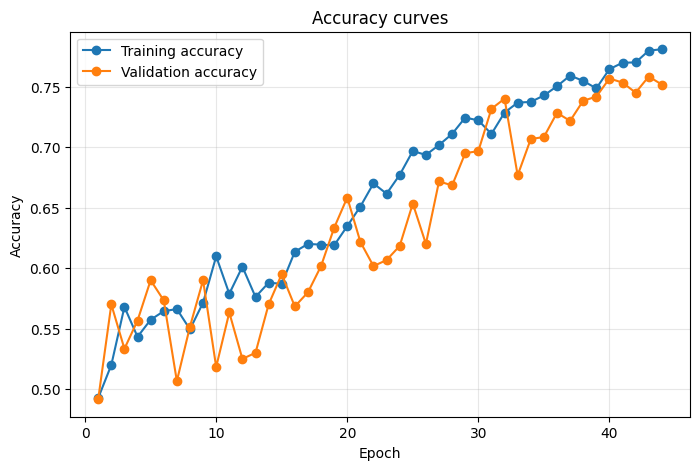

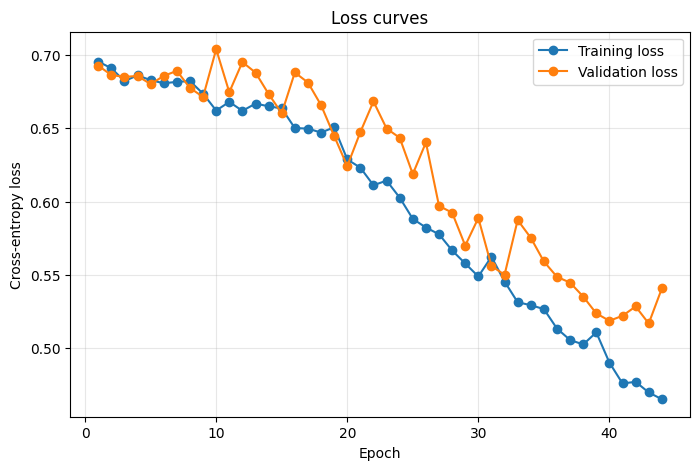

In [16]:
def plot_learning_curves(history):
    # Function to plot the training and validation accuracy and loss curves.
    if history is None:
        print('Train the model first.')
        return

    # Extract history data.
    h = history.history
    epochs = range(1, len(h['loss']) + 1)

    # Plot training and validation accuracy.
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, h['accuracy'], marker='o', label='Training accuracy')
    plt.plot(epochs, h['val_accuracy'], marker='o', label='Validation accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy curves')
    plt.grid(alpha=0.3); plt.legend(); plt.show()

    # Plot training and validation loss.
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, h['loss'], marker='o', label='Training loss')
    plt.plot(epochs, h['val_loss'], marker='o', label='Validation loss')
    plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.title('Loss curves')
    plt.grid(alpha=0.3); plt.legend(); plt.show()

# Call the function to plot the learning curves from the training history.
plot_learning_curves(history)

## STUDENT TODO 4 — Test
Use the test set as a final exam, not as repeated feedback for redesigning the model.

In [17]:
# STUDENT TODO 4: TEST THE CNN
# Use model.evaluate(x_test, y_test_one_hot, verbose=0).
# Save the outputs as test_loss and test_accuracy, then print accuracy as a percent.

print('Evaluating the model on the test set...')
# Evaluate the trained model on the test dataset to get final loss and accuracy.
# verbose=0 suppresses progress bar during evaluation.
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

# Print the test loss and accuracy, formatting accuracy as a percentage.
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

Evaluating the model on the test set...
Test Loss: 0.5634
Test Accuracy: 73.00%


## Individual predictions
Softmax confidence is not certainty. A confident prediction can still be wrong.

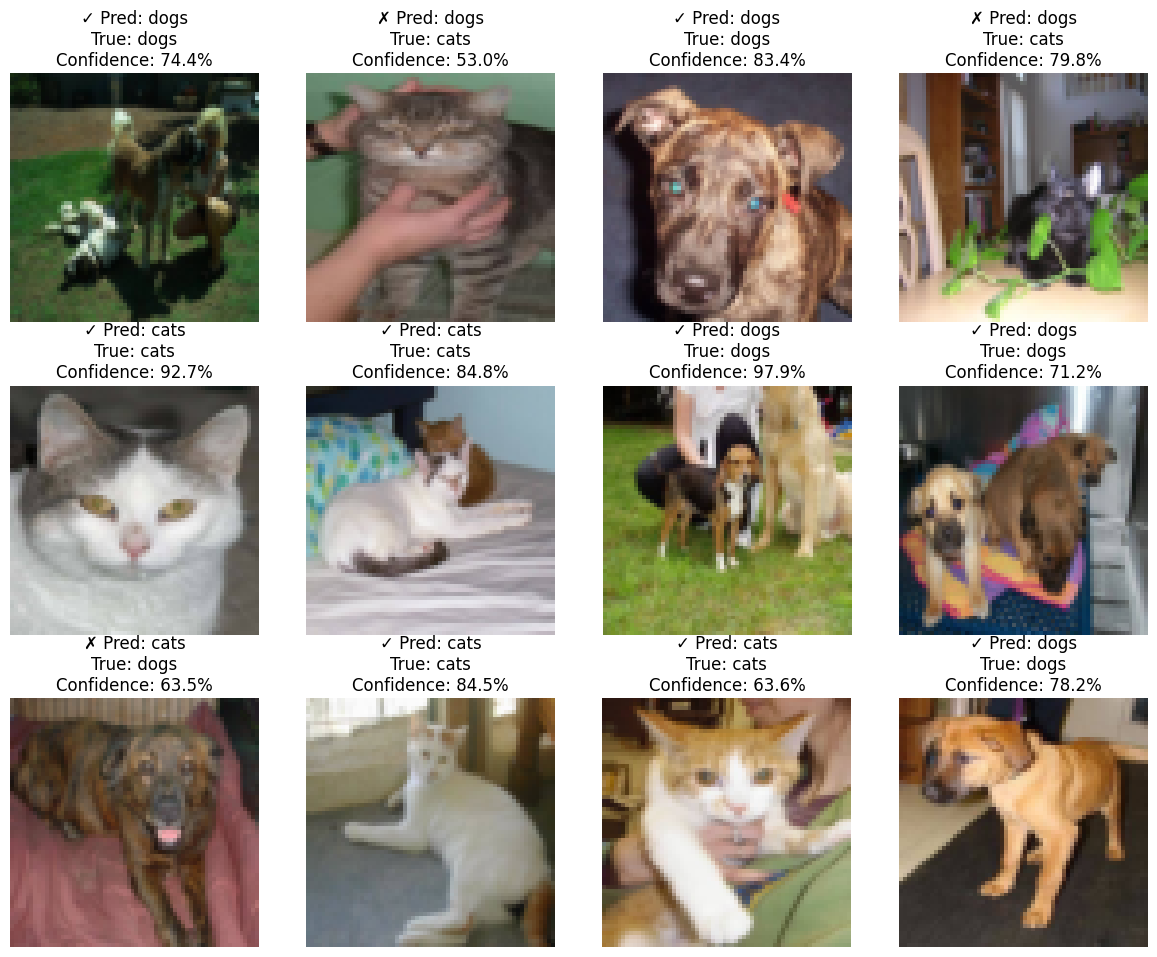

In [18]:
def show_predictions(model, images, labels, class_names, count=12):
    # Function to display a grid of images with their predicted and true labels, along with confidence.
    if model is None or images is None:
        print('Finish normalization and training first.')
        return

    # Limit the number of images to display.
    count = min(count, len(images))
    # Get model predictions (probabilities) for the selected images.
    probs = model.predict(images[:count], verbose=0)
    # Get the class with the highest probability as the prediction.
    preds = np.argmax(probs, axis=1)

    # Determine grid layout for plotting.
    cols, rows = 4, int(np.ceil(count / 4))
    plt.figure(figsize=(12, 3.2 * rows))

    # Iterate through images and plot them.
    for i in range(count):
        plt.subplot(rows, cols, i + 1)
        # Display the image, clipping values to [0, 1] for correct display.
        plt.imshow(np.clip(images[i], 0, 1))
        p, t = int(preds[i]), int(labels[i])
        # Mark prediction as correct (✓) or incorrect (✗).
        mark = '✓' if p == t else '✗'
        # Set title with prediction, true label, and confidence.
        plt.title(f'{mark} Pred: {class_names[p]}\nTrue: {class_names[t]}\nConfidence: {100*probs[i,p]:.1f}%')
        plt.axis('off') # Hide axes.
    plt.tight_layout(); plt.show() # Adjust layout and display plot.

# Check if test data is normalized before attempting to show predictions.
if x_test is None:
    print('Normalize the data first.')
else:
    # Display predictions for a subset of the test set.
    show_predictions(model, x_test, y_test, class_names)

## Confusion matrix
Entry $C_{ij}$ counts images whose true class is $i$ and predicted class is $j$. Diagonal values are correct; off-diagonal values reveal specific mistakes.

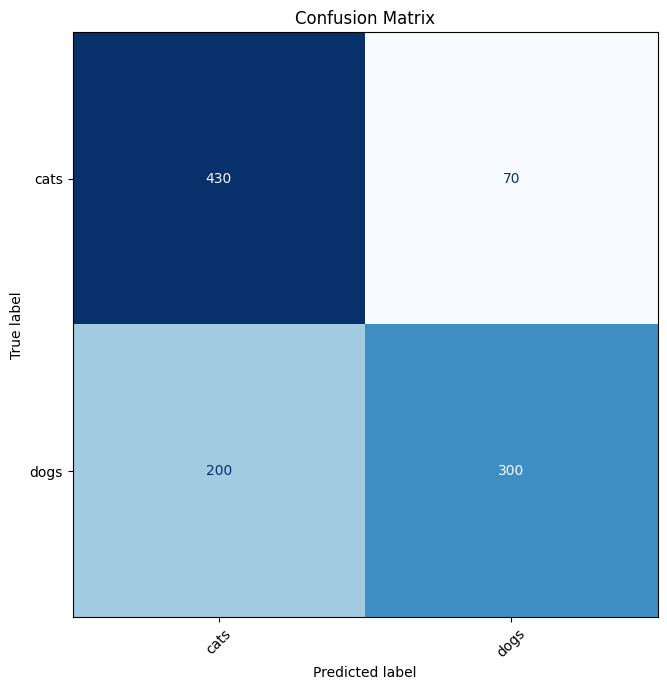

In [19]:
def plot_confusion(model, images, labels, class_names):
    # Function to plot a confusion matrix showing true vs. predicted labels.
    if model is None or images is None:
        print('Finish normalization and training first.')
        return

    # Get model predictions for the input images.
    preds = np.argmax(model.predict(images, verbose=0), axis=1)
    # Compute the confusion matrix.
    matrix = confusion_matrix(labels, preds)

    # Determine appropriate figure size based on the number of classes.
    size = max(7, 0.65 * len(class_names))
    fig, ax = plt.subplots(figsize=(size, size))
    # Display the confusion matrix using ConfusionMatrixDisplay.
    ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(
        ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False
    )
    plt.title('Confusion Matrix'); plt.tight_layout(); plt.show()

# Check if test data is normalized before plotting the confusion matrix.
if x_test is None:
    print('Normalize the data first.')
else:
    # Plot the confusion matrix for the test set.
    plot_confusion(model, x_test, y_test, class_names)

## Class-wise Accuracies
Let's analyze the model's performance for each class individually.

In [20]:
print('Calculating class-wise accuracies...')

# Iterate through each class to calculate and print its accuracy.
for i, class_name in enumerate(class_names):
    # Filter x_test and y_test to include only samples belonging to the current class.
    class_indices = np.where(y_test == i)
    x_test_class = x_test[class_indices]
    y_test_class = y_test[class_indices]

    # If there are samples for this class in the test set, evaluate the model.
    if len(y_test_class) > 0:
        # Evaluate the model on the class-specific subset.
        _, class_accuracy = model.evaluate(x_test_class, y_test_class, verbose=0)
        # Print the accuracy for the current class.
        print(f'Accuracy for {class_name}: {class_accuracy * 100:.2f}% ({len(y_test_class)} samples)')
    else:
        print(f'No test samples found for class: {class_name}')

Calculating class-wise accuracies...
Accuracy for cats: 86.00% (500 samples)
Accuracy for dogs: 60.00% (500 samples)


## Class-wise Accuracy Bar Plot

Calculating class-wise accuracies for plotting...
Accuracy for cats: 86.00% (500 samples)
Accuracy for dogs: 60.00% (500 samples)


/tmp/ipykernel_4968/2499287229.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Accuracy (%)', data=accuracy_df, palette='viridis')


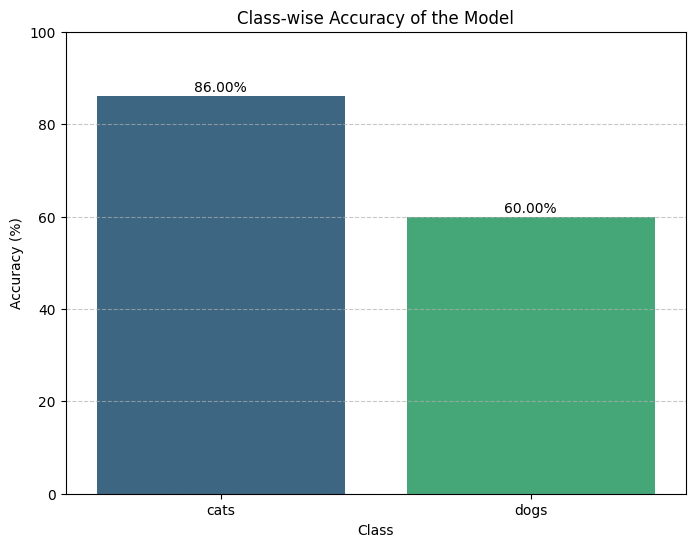

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dictionary to store class-wise accuracies.
class_accuracies = {}

print('Calculating class-wise accuracies for plotting...')

# Iterate through each class to calculate its accuracy.
for i, class_name in enumerate(class_names):
    # Filter test data for the current class.
    class_indices = np.where(y_test == i)
    x_test_class = x_test[class_indices]
    y_test_class = y_test[class_indices]

    # If samples exist for the class, evaluate and store accuracy.
    if len(y_test_class) > 0:
        _, class_accuracy = model.evaluate(x_test_class, y_test_class, verbose=0)
        class_accuracies[class_name] = class_accuracy * 100
        print(f'Accuracy for {class_name}: {class_accuracy * 100:.2f}% ({len(y_test_class)} samples)')
    else:
        print(f'No test samples found for class: {class_name}')

# Create a Pandas DataFrame from the class accuracies for easy plotting.
accuracy_df = pd.DataFrame(class_accuracies.items(), columns=['Class', 'Accuracy (%)'])

# Create a bar plot using Seaborn to visualize class-wise accuracies.
plt.figure(figsize=(8, 6))
sns.barplot(x='Class', y='Accuracy (%)', data=accuracy_df, palette='viridis')
plt.title('Class-wise Accuracy of the Model')
plt.ylim(0, 100) # Set y-axis limit from 0 to 100%.
plt.ylabel('Accuracy (%)')
plt.xlabel('Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add accuracy values on top of each bar for better readability.
for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy (%)'] + 1, f'{row['Accuracy (%)']:.2f}%', color='black', ha="center")

plt.show()

## Grad-CAM mathematics

Grad-CAM estimates which spatial locations supported class $c$. For feature map $A^k$,
$
\alpha_k^c=\frac{1}{Z}\sum_{i,j}\frac{\partial s^c}{\partial A_{i,j}^k},
$

and

$
L_{\text{Grad-CAM}}^c=\operatorname{ReLU}\left(\sum_k\alpha_k^c A^k\right).
$

Bright areas strongly supported the selected class. This is useful evidence, but it is not proof that the CNN understands the image like a human.


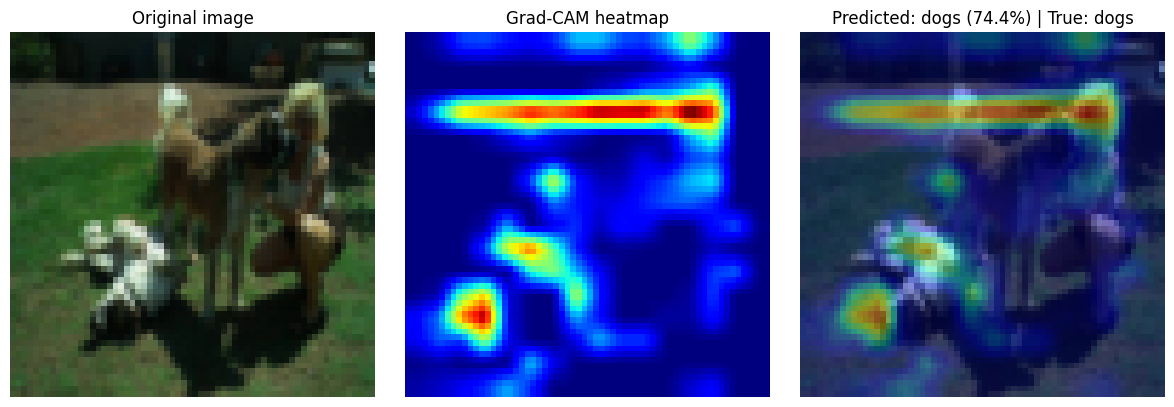

In [22]:
def last_conv_layer(model):
    """Return the final Conv2D layer in a model."""
    # Iterate through layers in reverse to find the last Conv2D layer.
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer

    raise ValueError("Grad-CAM requires at least one Conv2D layer.")


def build_gradcam_model(model, image_shape):
    """
    Create a functional model for Grad-CAM without using model.output.

    Some Keras Sequential models do not expose model.output as a symbolic
    tensor. We create a fresh symbolic input and pass it through the trained
    layers while reusing all learned weights.
    """
    # Identify the target convolutional layer for Grad-CAM.
    target_conv_layer = last_conv_layer(model)

    # Create a symbolic input for the Grad-CAM model.
    symbolic_input = keras.Input(
        shape=image_shape,
        name="gradcam_input"
    )
    x = symbolic_input
    convolution_features = None

    # Pass the input through the model's layers, reusing weights.
    for layer in model.layers:
        # Disable Dropout and random augmentation during explanation.
        try:
            x = layer(x, training=False)
        except TypeError:
            x = layer(x)

        # Capture features from the target convolutional layer.
        if layer is target_conv_layer:
            convolution_features = x

    if convolution_features is None:
        raise ValueError(
            "The final Conv2D layer was not connected to the prediction."
        )

    # Return a Keras Model that outputs both the convolutional features and the final predictions.
    return keras.Model(
        inputs=symbolic_input,
        outputs=[convolution_features, x],
        name="gradcam_model"
    )


def make_gradcam_heatmap(image_batch, model, class_index=None):
    """Compute a normalized Grad-CAM heatmap for one image."""
    # Build the Grad-CAM specific model.
    grad_model = build_gradcam_model(
        model,
        image_shape=tuple(image_batch.shape[1:])
    )

    # Record operations for gradient computation.
    with tf.GradientTape() as tape:
        # Pass the image batch through the Grad-CAM model.
        features, predictions = grad_model(
            image_batch,
            training=False
        )

        # If class_index is not provided, use the predicted class.
        if class_index is None:
            class_index = tf.argmax(predictions[0])

        # Select the score for the target class.
        selected_score = predictions[:, class_index]

    # Compute gradients of the selected score with respect to the convolutional features.
    gradients = tape.gradient(
        selected_score,
        features
    )

    if gradients is None:
        raise RuntimeError(
            "Gradients could not be computed. Check that the CNN's final "
            "Conv2D layer is connected to the output."
        )

    # Average the gradients across spatial dimensions.
    weights = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    # Compute a weighted sum of the feature maps to get the heatmap.
    heatmap = tf.reduce_sum(
        features[0] * weights,
        axis=-1
    )

    # Apply ReLU to the heatmap and normalize it to the range [0, 1].
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + keras.backend.epsilon()
    )

    return heatmap.numpy(), int(class_index)


def show_gradcam(model, image, class_names, true_label=None):
    """Show the image, Grad-CAM heatmap, and an overlay."""
    if model is None:
        print("Define and train the model first.")
        return

    # Expand image dimensions to create a batch of 1 image.
    image_batch = np.expand_dims(
        image,
        axis=0
    ).astype("float32")

    # Get model probabilities for the input image.
    probabilities = model.predict(
        image_batch,
        verbose=0
    )[0]

    # Get the index of the predicted class.
    predicted_index = int(np.argmax(probabilities))

    # Generate the Grad-CAM heatmap.
    heatmap, _ = make_gradcam_heatmap(
        image_batch,
        model,
        class_index=predicted_index
    )

    # Resize the heatmap to the original image dimensions.
    resized_heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        image.shape[:2]
    ).numpy().squeeze()

    # Prepare image for display and create a colored overlay of heatmap on image.
    display_image = np.clip(image, 0, 1)
    colored_heatmap = plt.cm.jet(resized_heatmap)[..., :3]
    overlay = np.clip(
        0.60 * display_image + 0.40 * colored_heatmap,
        0,
        1
    )

    # Construct the title for the plot.
    title = (
        f"Predicted: {class_names[predicted_index]} "
        f"({100 * probabilities[predicted_index]:.1f}%)"
    )
    if true_label is not None:
        title += f" | True: {class_names[int(true_label)]}"

    # Plot the original image, heatmap, and overlay.
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(display_image)
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(resized_heatmap, cmap="jet")
    plt.title("Grad-CAM heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(title)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


gradcam_index = 0 # Index of the image from the test set to visualize Grad-CAM for.

# Check if images are normalized before using Grad-CAM.
if x_test is None:
    print("Normalize the images before using Grad-CAM.")
else:
    # Show Grad-CAM visualization for a specific test image.
    show_gradcam(
        model,
        x_test[gradcam_index],
        class_names,
        true_label=y_test[gradcam_index]
    )

## Reflection
1. Which gesture was confused most often?
2. Did Grad-CAM focus on the hand or background?
3. Why could an unfamiliar hand position cause an error?
4. Was performance meaningfully above chance (33.3%)?
5. Describe one change you would test next.
6. Explain training, validation, and test data.
7. Why is Grad-CAM not unquestionable proof?

## Optional controlled experiment
Change exactly one item: filter count, convolution depth, augmentation, dropout, batch size, or epoch count. Compare training, validation, test, and Grad-CAM results.

# Upload your own image!

In [23]:
## STUDENT TO DO: Complete the "YOUR CODE" lines; use materials from above cells

from google.colab import files
import io

print('Upload an image of a cat or dog:')
# Prompt the user to upload a file.
uploaded = files.upload()

# Iterate through each uploaded file.
for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')

    # Read the uploaded image using PIL, convert to RGB, and resize to model's input size.
    img = Image.open(io.BytesIO(uploaded[fn]))
    img = img.convert('RGB')
    img = img.resize((64, 64), Image.Resampling.BILINEAR)
    img_array = np.asarray(img, dtype=np.uint8)

    ## STUDENT TO DO
    # Replace None with YOUR CODE; Normalize the img_array image (similar to x_train, x_test normalization)
    # Normalize the image pixel values from [0, 255] to [0, 1].
    img_normalized = img_array.astype(np.float32) / 255.0 # Normalized as done in cell 5aaff724

    # Add a batch dimension to the image array (model expects a batch of images).
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Make prediction
    # STUDENT TO DO: Replace None with YOUR CODE, use model.predict() on img_batch, use verbose=0
    # Use the trained model to predict the class probabilities for the uploaded image.
    predictions = model.predict(img_batch, verbose=0) # Use the trained model for prediction

    # Get the index of the predicted class and its corresponding class name and confidence.
    predicted_class_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_index]
    confidence = predictions[0][predicted_class_index]

    # Display the original uploaded image with the model's prediction and confidence.
    plt.imshow(img_array)
    plt.title(f'Prediction: {predicted_class} (Confidence: {100 * confidence:.2f}%)')
    plt.axis('off')
    plt.show()

Upload an image of a cat or dog:


KeyboardInterrupt: 